In [1]:
import pandas as pd

# 1 - mzML parser ON
#### input mzml/AMP_ON
#### output mzml_parsed/ON

In [52]:
# Submit the SLURM job for mzml_parser_1.sh
!sbatch core/backend/mzml_parser_1_AMP.sh


Submitted batch job 20110894


In [10]:
# sum = pd.read_parquet('Projects/STD/mzml_parsed/ON/sum/df_transition_summed_1_test.parquet')
# sum

In [53]:
import pandas as pd
df = pd.read_parquet('Projects/AMP/mzml_parsed/ON/df_mzml_parser_1_AMP.parquet')
# Print number of unique Sample_ID
print(len(df['Sample_ID'].unique()))
df

42


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
0,None,227.1,183.0,0.011583,40.640003,11162023_Blank-AMP_2x_MRMs_O3on_01,227.1 -> 183.0
1,None,227.1,183.0,0.024483,40.680004,11162023_Blank-AMP_2x_MRMs_O3on_01,227.1 -> 183.0
2,None,227.1,183.0,0.037383,40.640003,11162023_Blank-AMP_2x_MRMs_O3on_01,227.1 -> 183.0
3,None,227.1,183.0,0.050317,40.640003,11162023_Blank-AMP_2x_MRMs_O3on_01,227.1 -> 183.0
4,None,227.1,183.0,0.063233,40.640003,11162023_Blank-AMP_2x_MRMs_O3on_01,227.1 -> 183.0
...,...,...,...,...,...,...,...
5121228,None,533.5,183.0,29.949033,41.620003,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
5121229,None,533.5,183.0,29.961967,41.600002,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
5121230,None,533.5,183.0,29.974883,41.540005,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
5121231,None,533.5,183.0,29.987800,41.480003,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0


In [8]:
unique_values = df['Sample_ID'].unique()
print(unique_values)


['11162023_Blank-AMP_2x_MRMs_O3on_01'
 '11162023_WT-m1-cereb-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m1-cortex-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m1-dienc-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m2-cereb-FAD246_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m2-cortex-FAD249_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m2-dienc-FAD249_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m2-hippo-FAD249_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m3-cereb-FAD263_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m3-cortex-FAD263_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m3-dienc-FAD263_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m3-hippo-FAD263_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m4-cereb-FAD263_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m4-cortex-FAD263_AMP_2x_0.05uMd216-0_MRMs_O3on_01'
 '11162023_WT-m4-cortex-FAD263_AMP_2x_0.05uMd216-0_MRMs_O3on_0

In [9]:
# Ensure the Parent_Ion column is numeric
df['Parent_Ion'] = pd.to_numeric(df['Parent_Ion'], errors='coerce')

# Set tolerance for Parent_Ion comparison
tolerance = 0.2

# Filter based on Parent_Ion and Retention_Time window
df_filtered = df[(df['Parent_Ion'] >= 423.4 - tolerance) & 
                 (df['Parent_Ion'] <= 423.4 + tolerance) &
                 (df['Retention_Time'] >= 5) &
                 (df['Retention_Time'] <= 15)]

# Sort the filtered DataFrame by Retention_Time
df_filtered_sorted = df_filtered.sort_values(by='Retention_Time', ascending=True)

# Display the sorted DataFrame
df_filtered_sorted


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
3798668,None,423.3,183.0,5.005800,49.420002,11192023_5xFAD-m1-dienc-FAD249_AMP_2x_0.05uMd2...,423.3 -> 183.0
62476,None,423.3,183.0,5.005817,41.060001,11162023_Blank-AMP_2x_MRMs_O3on_01,423.3 -> 183.0
3311893,None,423.3,183.0,5.005817,157.060013,11192023_5xFAD-m1-cereb-FAD249_AMP_2x_0.05uMd2...,423.3 -> 183.0
3070191,None,423.3,183.0,5.005817,80.680008,11162023_WT-m5-hippo-FAD263_AMP_2x_0.05uMd216-...,423.3 -> 183.0
3926379,None,423.3,183.0,5.005817,96.240005,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0
...,...,...,...,...,...,...,...
4678887,None,423.3,183.0,14.993267,430.640045,11192023_5xFAD-m2-dienc-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0
1400435,None,423.3,183.0,14.993267,508.760040,11162023_WT-m3-dienc-FAD263_AMP_2x_0.05uMd216-...,423.3 -> 183.0
5062020,None,423.3,183.0,14.993267,90.440010,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,423.3 -> 183.0
1655857,None,423.3,183.0,14.993283,567.240051,11162023_WT-m4-cereb-FAD263_AMP_2x_0.05uMd216-...,423.3 -> 183.0


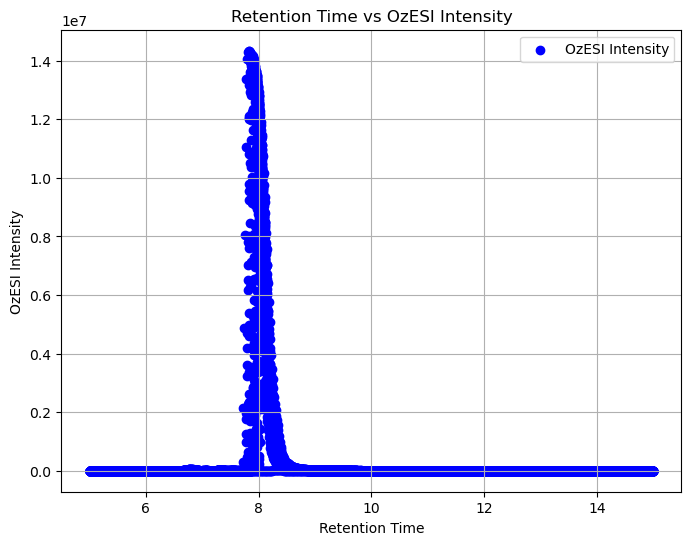

In [10]:
import matplotlib.pyplot as plt

# Plot the filtered data
plt.figure(figsize=(8, 6))
plt.scatter(df_filtered_sorted['Retention_Time'], df_filtered_sorted['OzESI_Intensity'], color='blue', label='OzESI Intensity')

# Add labels and title
plt.xlabel('Retention Time')
plt.ylabel('OzESI Intensity')
plt.title('Retention Time vs OzESI Intensity')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()


# 2 - Sample

In [22]:
input_dir = 'Projects/AMP/mzml_parsed/ON/'
import glob; num_files = len(glob.glob('Projects/AMP/samples/ON/*.parquet'))
num_files   


1

In [21]:
# change mzml parsed df
step1 = pd.read_parquet('Projects/AMP/mzml_parsed/ON/df_mzml_parser_1_AMP.parquet')
step1 = step1[step1['Sample_ID'] == '11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3on_01']
step1.to_parquet('Projects/AMP/mzml_parsed/ON/hippo_m1_FAD245_WT.parquet')


step1

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
468184,None,227.1,183.0,0.011583,41.240002,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0
468185,None,227.1,183.0,0.024483,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0
468186,None,227.1,183.0,0.037383,41.200005,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0
468187,None,227.1,183.0,0.050317,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0
468188,None,227.1,183.0,0.063233,41.180004,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0
...,...,...,...,...,...,...,...
595890,None,533.5,183.0,29.949033,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0
595891,None,533.5,183.0,29.961950,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0
595892,None,533.5,183.0,29.974867,41.280003,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0
595893,None,533.5,183.0,29.987783,41.060001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0


In [41]:
# Submit the SLURM job for !sbatch core/backend/sample_2.sh
!sbatch core/backend/sample_2_AMP.sh


Submitted batch job 20505268


In [44]:
import pandas as pd
df = pd.read_parquet('Projects/AMP/samples/ON/df_sample_2_hippo_WT_m1_FAD245_ON.parquet')
#print number of unique Sample_ID
print(df['Sample_ID'].unique())
df

['11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-0_MRMs_O3on_01']


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area
0,None,227.1,183.0,0.011583,41.240002,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
1,None,227.1,183.0,0.024483,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
2,None,227.1,183.0,0.037383,41.200005,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
3,None,227.1,183.0,0.050317,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
4,None,227.1,183.0,0.063233,41.180004,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
...,...,...,...,...,...,...,...,...,...,...,...,...
127706,None,533.5,183.0,29.949033,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
127707,None,533.5,183.0,29.961950,41.220001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
127708,None,533.5,183.0,29.974867,41.280003,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205
127709,None,533.5,183.0,29.987783,41.060001,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205


# 3 - Match
#### input sample/ON
#### output match/ON

In [45]:
input_dir = 'Projects/AMP/samples/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
num_files


1

In [46]:
# Submit the SLURM job for !sbatch core/backend/match_3.sh
!sbatch core/backend/match_3_AMP.sh


Submitted batch job 20507631


In [47]:
import pandas as pd
df = pd.read_parquet('Projects/AMP/match/ON/df_match_3_hippo_WT_m1_FAD245.parquet')
#print unqiue vlaues of Lipid in df
#print(df['Lipid'].unique())

df

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area,STD_RT_Dif,Species,Adjusted_RT,Class,STD_RT_OFF
0,,227.1,183.0,3.577567,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,,7.899783
1,,227.1,183.0,3.590483,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,,7.899783
2,,227.1,183.0,3.603400,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,,7.899783
3,,227.1,183.0,3.616317,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,,7.899783
4,,227.1,183.0,3.629233,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,227.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,,7.899783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182995,,533.5,183.0,4.185833,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,,7.899783
182996,,533.5,183.0,4.198767,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,,7.899783
182997,,533.5,183.0,4.211683,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,,7.899783
182998,,533.5,183.0,4.224600,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,533.5 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,,7.899783


In [5]:
# # Ensure the Parent_Ion column is numeric
# df['Parent_Ion'] = pd.to_numeric(df['Parent_Ion'], errors='coerce')

# # Set tolerance for Parent_Ion comparison
# tolerance = 0.2

# # Filter based on Parent_Ion and Retention_Time window
# df_filtered = df[(df['Parent_Ion'] >= 423.4 - tolerance) & 
#                  (df['Parent_Ion'] <= 423.4 + tolerance) &
#                  (df['Retention_Time'] >= 14) &
#                  (df['Retention_Time'] <= 15) ]

# # Sort the filtered DataFrame by Retention_Time
# df_filtered_sorted = df_filtered.sort_values(by='Retention_Time', ascending=True)

# # Print each Lipid value on a new line
# for lipid in df_filtered_sorted['Lipid']:
#     print(lipid)


# # Display the sorted DataFrame
# df_filtered_sorted


In [49]:
df[df['Lipid'].str.contains('16:1', case=False, na=False)]

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,STD_Peak_Intensity,STD_Peak_Area,STD_RT_Dif,Species,Adjusted_RT,Class,STD_RT_OFF
77,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,241.1,183.0,3.577367,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
78,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,241.1,183.0,3.590283,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
79,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,241.1,183.0,3.603200,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
80,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,241.1,183.0,3.616117,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
81,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,241.1,183.0,3.629033,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,10:1,4.066533,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180814,FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 | FA(17:1)_...,409.3,183.0,4.179533,1612.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
180815,FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 | FA(17:1)_...,409.3,183.0,4.192450,941.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
180816,FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 | FA(17:1)_...,409.3,183.0,4.205367,805.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783
180817,FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 | FA(17:1)_...,409.3,183.0,4.218283,1250.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,557499.375,97348.723205,0.038767,9:1,3.743933,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,7.899783


In [8]:
# ozon_database = pd.read_parquet('lipid_database/OzON_databases/OzON_Possible_Database_0.parquet')
# ozon_database

# # Filter the OzON database for rows where Parent_Ion is 423.4
# filtered_data = ozon_database[ozon_database['Parent_Ion'] == 423.4]

# filtered_data


# 4 - group
#### input match/ON
#### output group/ON

In [51]:
input_dir = 'Projects/AMP/match/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
num_files


1

In [52]:
!sbatch core/backend/group_4_AMP.sh

Submitted batch job 20507643


In [54]:
import pandas as pd
df_before = pd.read_parquet('Projects/AMP/group/ON/df_group_4_hippo_WT_m1_FAD245.parquet')
#print unqiue columns
print(df_before.columns)
df_before

Index(['Lipid', 'Parent_Ion', 'Product_Ion', 'Retention_Time',
       'OzESI_Intensity', 'Sample_ID', 'Transition', 'Sample', 'STD',
       'STD_RT_ON', 'STD_Peak_Intensity', 'STD_Peak_Area', 'STD_RT_Dif',
       'Species', 'Adjusted_RT', 'Class', 'STD_RT_OFF', 'Possible_Lipids',
       'Biology', 'Genotype', 'Cage', 'Mouse', 'group_by_ion',
       'group_by_lipid'],
      dtype='object')


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,...,Adjusted_RT,Class,STD_RT_OFF,Possible_Lipids,Biology,Genotype,Cage,Mouse,group_by_ion,group_by_lipid
0,FA(10:1)_<>_n-2,325.2,183.0,3.369017,131.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.859817,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,0
1,FA(10:1)_<>_n-2,325.2,183.0,3.381933,103.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.859817,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,0
2,FA(10:1)_<>_n-2,325.2,183.0,3.394867,72.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.859817,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,0
3,FA(10:1)_<>_n-2,325.2,183.0,3.407783,150.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.859817,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,0
4,FA(10:1)_<>_n-2,325.2,183.0,3.420700,245.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.859817,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62303,FA(9:1)_<>_n-7,241.1,183.0,4.184617,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.743933,FA,7.899783,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,hippo,WT,FAD245,m1,0,433
62304,FA(9:1)_<>_n-7,241.1,183.0,4.197533,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.743933,FA,7.899783,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,hippo,WT,FAD245,m1,0,433
62305,FA(9:1)_<>_n-7,241.1,183.0,4.210450,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.743933,FA,7.899783,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,hippo,WT,FAD245,m1,0,433
62306,FA(9:1)_<>_n-7,241.1,183.0,4.223367,41.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,241.1 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,3.743933,FA,7.899783,FA(8:1)_<>_n-6 | FA(9:1)_<>_n-7 | FA(10:1)_<>_...,hippo,WT,FAD245,m1,0,433


In [3]:
df[df['Lipid'].str.contains('18:1', case=False, na=False)]

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_ON,...,Adjusted_RT,Class,STD_RT_OFF,Possible_Lipids,Biology,Genotype,Cage,Mouse,group_by_ion,group_by_lipid
17305,FA(18:1)_<>_n-10,325.2,183.0,8.201233,315.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.699417,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,128
17306,FA(18:1)_<>_n-10,325.2,183.0,8.214150,260.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.699417,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,128
17307,FA(18:1)_<>_n-10,325.2,183.0,8.227083,206.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.699417,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,128
17308,FA(18:1)_<>_n-10,325.2,183.0,8.240000,149.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.699417,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,128
17309,FA(18:1)_<>_n-10,325.2,183.0,8.252917,103.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.699417,FA,7.899783,FA(10:1)_<>_n-2 | FA(12:1)_<>_n-4 | FA(12:2)_<...,hippo,WT,FAD245,m1,8,128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19630,FA(18:1)_<>_n-9,339.3,183.0,9.441183,216.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.996583,FA,7.899783,FA(12:1)_<>_n-3 | FA(12:2)_<F>_n-3 | FA(13:1)_...,hippo,WT,FAD245,m1,10,142
19631,FA(18:1)_<>_n-9,339.3,183.0,9.454100,244.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.996583,FA,7.899783,FA(12:1)_<>_n-3 | FA(12:2)_<F>_n-3 | FA(13:1)_...,hippo,WT,FAD245,m1,10,142
19632,FA(18:1)_<>_n-9,339.3,183.0,9.467033,255.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.996583,FA,7.899783,FA(12:1)_<>_n-3 | FA(12:2)_<F>_n-3 | FA(13:1)_...,hippo,WT,FAD245,m1,10,142
19633,FA(18:1)_<>_n-9,339.3,183.0,9.479950,232.0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,None,7.861017,...,8.996583,FA,7.899783,FA(12:1)_<>_n-3 | FA(12:2)_<F>_n-3 | FA(13:1)_...,hippo,WT,FAD245,m1,10,142


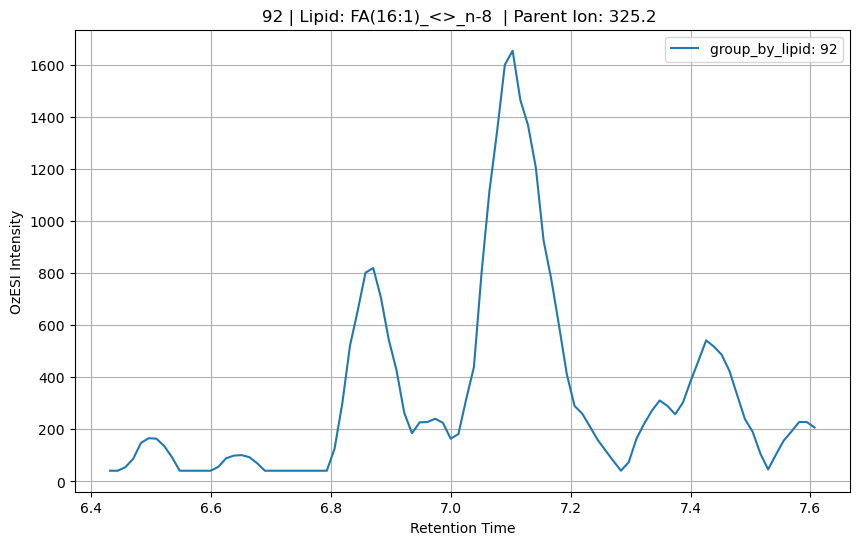

In [14]:
import matplotlib.pyplot as plt

# Function to plot the chromatogram for a specific group_by_lipid value
def plot_chromatogram(df, group_value):
    group_data = df[df['group_by_lipid'] == group_value]
    
    # Ensure the Retention_Time is sorted
    group_data = group_data.sort_values(by='Retention_Time')
    
    # Extract Lipid, Parent Ion, and Isomer values from the first row of the group
    lipid = group_data['Lipid'].iloc[0] if not group_data.empty else "Unknown Lipid"
    parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
    # isomer = group_data['Isomer'].iloc[0] if not group_data.empty else "Unknown Isomer"
    
    plt.figure(figsize=(10, 6))
    plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'group_by_lipid: {group_value}')
    plt.xlabel('Retention Time')
    plt.ylabel('OzESI Intensity')
    
    # Add Lipid, Parent Ion, and Isomer to the title
    plt.title(f'{group_value} | Lipid: {lipid} | Parent Ion: {parent_ion} ')
    
    plt.legend()
    plt.grid(True)
    plt.show()

# Define the specific group_by_lipid value you are interested in
specific_group_by_lipid_value = 92  # Replace with the actual value you are interested in

# Call the function to plot the chromatogram
plot_chromatogram(df_before, specific_group_by_lipid_value)


# 5 - Analysis

In [55]:
input_dir = 'Projects/AMP/group/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
num_files



1

In [85]:
!sbatch core/backend/analysis_5_AMP.sh

Submitted batch job 20507920


In [86]:
import pandas as pd
df_analysis = pd.read_parquet('Projects/AMP/analysis/ON/df_analysis_5_hippo_WT_m1_FAD245.parquet')
#print number of unqiue values
#print(df_analysis['Lipid'].unique())
#print unique lipid values for Lipid FA(20:1)
# df_analysis
# df_analysis[df_analysis['Lipid'].str.contains('24:1', case=False, na=False)]
# df_analysis.to_csv('Projects/STD/analysis/ON/df_analysis_5_FAME.csv', index=False)
# Assuming df_analysis is your DataFrame
for index, row in df_analysis.iterrows():
    print(f"Lipid: {row['Lipid']}, Prominence: {row['Prominence']}")

df_analysis




Lipid: FA(10:1)_<>_n-2 , Prominence: 168.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 2721.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 3235898.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 61.0
Lipid: FA(10:1)_<>_n-2 , Prominence: 135.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 3602.0
Lipid: FA(10:1)_<>_n-3 , Prominence: 153923.0
Lipid: FA(12:1)_<>_n-2 , Prominence: 6049.0
Lipid: FA(12:1)_<>_n-2 , Prominence: 953.0
Lipid: FA(12:1)_<>_n-2 , Prominence: 949.0
Lipid: FA(12:1)_<>_n-2 , Prominence: 2034.0
Lipid: FA(12:1)_<>_n-2 , Prominence: 5009.0
Lipid: FA(12:1)_<>_n-2 , Prominence: 126577.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 32026.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 4764.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 16314.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 527751.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 45.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 312.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 151.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 318.0
Lipid: FA(12:1)_<>_n-3 , Prominence: 422.0
Lipid: FA(12:1)_<>_n-4 , Prominen

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,Biology,Genotype,Cage,Mouse,n_value
0,FA(10:1)_<>_n-2,3.549900,972.0,8,0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,1.352017e+04,7.233180e+03,1.000000,1.855702e+03,0,hippo,WT,FAD245,m1,2
1,FA(10:1)_<>_n-2,3.679117,5666.0,8,0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,4.856406e+04,-4.607558e+04,1.000000,7.715619e+03,1,hippo,WT,FAD245,m1,2
2,FA(10:1)_<>_n-2,3.821233,3236218.0,8,0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,8.633514e+07,-4.327470e+07,1.250000,2.166747e+07,1,hippo,WT,FAD245,m1,2
3,FA(10:1)_<>_n-2,4.312200,902.0,8,0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,-3.923211e+03,-5.316709e+03,3.000000,1.006452e+03,0,hippo,WT,FAD245,m1,2
4,FA(10:1)_<>_n-2,4.441400,842.0,8,0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,8.977749e+02,-9.901935e+03,1.000000,2.165496e+03,0,hippo,WT,FAD245,m1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,FA(8:1)_<>_n-3,3.059950,56255.0,3,424,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,283.2 -> 183.0,hippo_WT_m1_FAD245,283.2,183.0,...,6.646916e+05,-1.048659e+06,0.666667,3.765259e+05,0,hippo,WT,FAD245,m1,3
787,FA(9:1)_<>_n-2,3.421100,5556.0,6,428,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,1.151558e+05,-5.004169e+04,1.666667,9.316093e+03,1,hippo,WT,FAD245,m1,2
788,FA(9:1)_<>_n-2,3.602000,155122.0,6,428,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,3.062699e+06,-3.615948e+06,0.600000,6.762025e+05,1,hippo,WT,FAD245,m1,2
789,FA(9:1)_<>_n-3,3.201867,3369.0,4,429,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,2.555308e+04,-9.440151e+03,0.250000,8.169676e+03,0,hippo,WT,FAD245,m1,3


In [87]:
#print columns of df_analysis
print(df_analysis.columns)

Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'Possible_Lipids', 'Peak_Height',
       'Prominence', 'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column',
       'STD_RT_ON', 'STD_RT_OFF', 'STD_RT_Dif', 'STD_Peak_Intensity',
       'STD_Peak_Area', 'Adjusted_RT', 'Slope_Left', 'Slope_Right',
       'Asymmetry_Factor', 'Baseline_Drift', 'Shoulder_Count', 'Biology',
       'Genotype', 'Cage', 'Mouse', 'n_value'],
      dtype='object')


In [84]:
import pandas as pd

# Filter rows where 'Species' is '18:1'
filtered_df = df_analysis[df_analysis['Species'] == '16:1']
#print unique column names
print(filtered_df.columns)

filtered_df


Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'Possible_Lipids', 'Peak_Height',
       'Prominence', 'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column',
       'STD_RT_ON', 'STD_RT_OFF', 'STD_RT_Dif', 'Slope_Left', 'Slope_Right',
       'Asymmetry_Factor', 'Baseline_Drift', 'Shoulder_Count', 'Biology',
       'Genotype', 'Cage', 'Mouse', 'n_value'],
      dtype='object')


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Slope_Left,Slope_Right,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,Biology,Genotype,Cage,Mouse,n_value
148,FA(16:1)_<>_n-2,6.621467,2662.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,1.905718e+04,-8.754014e+03,1.750000,4.647571e+03,1,hippo,WT,FAD245,m1,2
149,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,1.434060e+07,-1.149128e+07,2.142857,-1.422591e+06,1,hippo,WT,FAD245,m1,2
150,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,-3.180940e+05,-3.513944e+06,1.000000,6.893419e+05,0,hippo,WT,FAD245,m1,2
151,FA(16:1)_<>_n-2,7.138283,1137226.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,1.915522e+07,-6.663993e+06,1.800000,3.201426e+05,1,hippo,WT,FAD245,m1,2
152,FA(16:1)_<>_n-3,6.854850,10899.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,4.303410e+04,-1.137442e+04,1.000000,1.162204e+04,0,hippo,WT,FAD245,m1,3
153,FA(16:1)_<>_n-3,7.190783,3903.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,1.461499e+04,-1.593984e+04,1.000000,5.785494e+03,0,hippo,WT,FAD245,m1,3
154,FA(16:1)_<>_n-3,7.294150,3231.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,1.539072e+04,4.954839e+03,0.333333,1.605496e+04,0,hippo,WT,FAD245,m1,3
155,FA(16:1)_<>_n-3,7.358750,3672.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,7.081693e+03,-1.935484e+04,0.428571,5.473837e+03,0,hippo,WT,FAD245,m1,3
156,FA(16:1)_<>_n-3,7.513800,2526.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,9.212443e+01,-6.369893e+03,0.333333,2.979131e+03,0,hippo,WT,FAD245,m1,3
157,FA(16:1)_<>_n-5,7.062800,553.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,5.905991e+03,-6.089056e+02,1.000000,3.174194e+03,0,hippo,WT,FAD245,m1,5


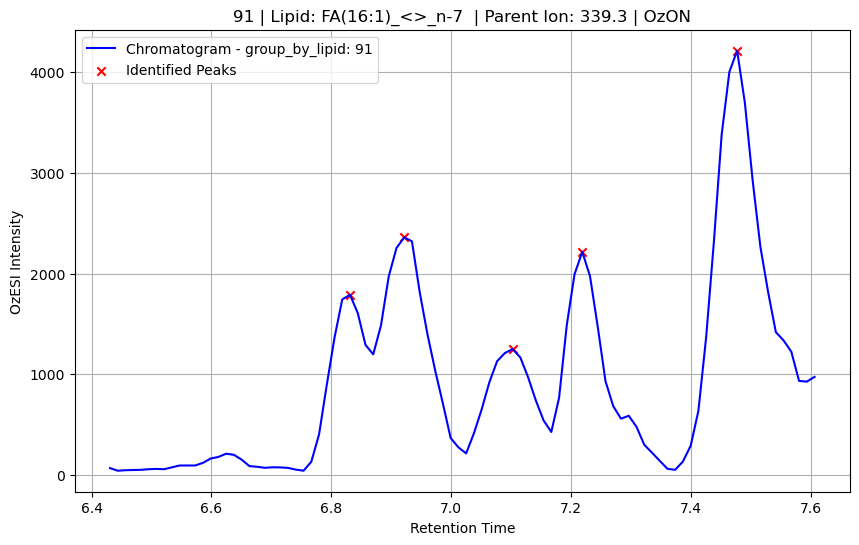

In [67]:
import matplotlib.pyplot as plt

# Function to plot the chromatogram for a specific group_by_lipid value, including analysis data (peaks)
def plot_chromatogram(df_grouped, df_analysis, group_value):
    """
    Plot the chromatogram for a specific group_by_lipid value.

    :param df_grouped: DataFrame containing the original grouped data.
    :param df_analysis: DataFrame containing the analyzed data (peaks).
    :param group_value: The specific group_by_lipid value to plot.
    """
    # Filter data for the specific group_by_lipid value
    group_data = df_grouped[df_grouped['group_by_lipid'] == group_value]
    analysis_data = df_analysis[df_analysis['group_by_lipid'] == group_value]
    
    # Ensure the Retention_Time is sorted in both DataFrames
    group_data = group_data.sort_values(by='Retention_Time')
    analysis_data = analysis_data.sort_values(by='Retention_Time')

    # Extract Lipid, Parent Ion, and Isomer values from the first row of the group
    lipid = group_data['Lipid'].iloc[0] if not group_data.empty else "Unknown Lipid"
    parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
    # isomer = group_data['Isomer'].iloc[0] if not group_data.empty else "Unknown Isomer"
    
    # Plot the grouped data (original chromatogram)
    plt.figure(figsize=(10, 6))
    plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'Chromatogram - group_by_lipid: {group_value}', color='blue')
    
    # Overlay the analysis data (peaks)
    if not analysis_data.empty:
        plt.scatter(analysis_data['Retention_Time'], analysis_data['OzESI_Intensity'], color='red', marker='x', label='Identified Peaks')

    # Add labels and title
    plt.xlabel('Retention Time')
    plt.ylabel('OzESI Intensity')
    
    # Add Lipid, Parent Ion, and Isomer to the title
    plt.title(f'{group_value} | Lipid: {lipid} | Parent Ion: {parent_ion} | OzON')
    
    # Add a legend and grid
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()

# Example: Define the specific group_by_lipid value you are interested in
specific_group_by_lipid_value = 91 # Replace with the actual value you are interested in

# Call the function to plot the chromatogram and analysis data
plot_chromatogram(df_before, df_analysis, specific_group_by_lipid_value)


In [17]:
# def filter_ozON_by_ozOFF(df_analysis, off_possible, retention_time_tolerance=0.3):
#     """
#     Filters df_analysis (OzON data) based on Retention_Time and Species from off_possible (OzOFF data)
#     with a user-defined tolerance for retention times, adjusting the OzON Retention_Time by STD_RT_Dif if it exists.
#     """
#     # Create a new column Adjusted_RT based on Retention_Time and STD_RT_Dif
#     if 'STD_RT_Dif' in df_analysis.columns:
#         df_analysis['Adjusted_RT'] = df_analysis['Retention_Time'] + df_analysis['STD_RT_Dif']
#     else:
#         df_analysis['Adjusted_RT'] = df_analysis['Retention_Time']

#     # Extract Species from Lipid names if not already present
#     if 'Species' not in df_analysis.columns:
#         df_analysis['Species'] = df_analysis['Lipid'].str.extract(r'\((\d+:\d+)\)')[0]

#     # Extract n-position from Lipid names
#     df_analysis['n_position'] = df_analysis['Lipid'].str.extract(r'n-(\d+)')[0].astype(int)

#     # Initialize an empty DataFrame to store the filtered results
#     filtered_df = pd.DataFrame()

#     # Iterate over each row in the off_possible (OzOFF data)
#     for _, row in off_possible.iterrows():
#         species = row['Species']
#         isomer_off = row['Isomer']
#         retention_time_off = row['Retention_Time']

#         # Define the retention time window based on the tolerance
#         retention_time_start = retention_time_off - retention_time_tolerance
#         retention_time_end = retention_time_off + retention_time_tolerance

#         # Filter df_analysis based only on species and retention time window
#         filtered_rows = df_analysis[
#             (df_analysis['Species'] == species) &
#             (df_analysis['Adjusted_RT'] >= retention_time_start) &
#             (df_analysis['Adjusted_RT'] <= retention_time_end)
#         ]

#         # Print matching action details for each row in df_analysis
#         for _, analysis_row in df_analysis.iterrows():
#             lipid = analysis_row['Lipid']
#             retention_time_on = analysis_row['Adjusted_RT']
#             n_position = analysis_row['n_position']
            
#             is_match = (
#                 (analysis_row['Species'] == species) and
#                 (retention_time_start <= retention_time_on <= retention_time_end)
#             )
            
#             print(f"Matching OzON: Lipid={lipid} (n-{n_position}), Adjusted_RT={retention_time_on} "
#                   f"with OzOFF: Species={species}, Isomer={isomer_off}, Retention_Time={retention_time_off}")
            
#             if is_match:
#                 print("Result: Match")
#             else:
#                 print("Result: No Match")

#         # Add the OzOFF isomer number to the matched rows
#         if not filtered_rows.empty:
#             filtered_rows = filtered_rows.assign(OzOFF_Isomer=isomer_off)
        
#         # Concatenate the filtered results to the overall filtered_df
#         filtered_df = pd.concat([filtered_df, filtered_rows], ignore_index=True)

#     # Identify lipids that were filtered out
#     for _, row in df_analysis.iterrows():
#         if row['Lipid'] not in filtered_df['Lipid'].values and row['Species'] == "18:1":
#             reason = "No matching OzOFF entry found within the retention time tolerance."
#             print(f"Filtered out Lipid: {row['Lipid']} (n-{row['n_position']}) because {reason}")

#     # Debugging: Print the final filtered DataFrame to verify its content
#     print("Final filtered DataFrame:")
#     print(filtered_df)

#     return filtered_df



# # # Example usage:
# # # Load the DataFrames
# # df_analysis = pd.read_parquet('Projects/AMP/analysis/ON/df_analysis_5_hippo_WT_m4_FAD263.parquet')
# # # Filter df_analysis for Species 18:1 before proceeding
# # df_analysis = df_analysis[df_analysis['Species'] == '18:1']

# # off_possible = pd.read_parquet('Projects/AMP/analysis/OFF/off_possible/df_analysis_5_hippo_WT_m4_FAD263_OFF_offpossible.parquet')

# # Example usage:
# # Load the DataFrames
# df_analysis = pd.read_parquet('Projects/AMP/analysis/ON/df_analysis_5_hippo_WT_m1_FAD245.parquet')
# # Filter df_analysis for Species 18:1 before proceeding
# df_analysis = df_analysis[df_analysis['Species'] == '16:1']

# off_possible = pd.read_parquet('Projects/AMP/analysis/OFF/off_possible/df_analysis_5_hippo_WT_m1_FAD245_OFF_offpossible.parquet')
# off_possible = pd.read_parquet('Projects/AMP/notpossible/rt_adjustment_6/df_rt_adjustment_6_hippo_WT_m1_FAD245_OFF.parquet')

# # Set the retention time tolerance (user can modify this)
# retention_time_tolerance = 0.05

# # Call the function to filter the OzON data based on OzOFF criteria and adjust by STD_RT_Dif
# filtered_ozON = filter_ozON_by_ozOFF(df_analysis, off_possible, retention_time_tolerance)


# # Display the filtered data with Isomer column
# #sort by lipid
# filtered_ozON = filtered_ozON.sort_values(by='Lipid')
# filtered_ozON


KeyError: 'Isomer'

In [62]:
# Assuming df_analysis is the new DataFrame in question
# We are filtering it to only include the specified columns if they exist

# List of required columns
required_columns = ['Lipid', 'Retention_Time', 'Prominence', 'Slope_Left', 'Slope_Right']

# Filter df_analysis for specified columns only if they exist
filtered_df_analysis = df_analysis.loc[:, [col for col in required_columns if col in df_analysis.columns]]

# Display all columns in filtered_df_analysis
filtered_df_analysis


,Lipid,Retention_Time,Prominence,Slope_Left,Slope_Right
148,FA(16:1)_<>_n-2,6.621467,1552.0,1.905718e+04,-8.754014e+03
149,FA(16:1)_<>_n-2,6.892800,847080.0,1.434060e+07,-1.149128e+07
150,FA(16:1)_<>_n-2,6.970317,16188.0,-3.180940e+05,-3.513944e+06
151,FA(16:1)_<>_n-2,7.138283,1134068.0,1.915522e+07,-6.663993e+06
152,FA(16:1)_<>_n-3,6.854850,1998.0,4.303410e+04,-1.137442e+04
153,FA(16:1)_<>_n-3,7.190783,850.0,1.461499e+04,-1.593984e+04
154,FA(16:1)_<>_n-3,7.294150,76.0,1.539072e+04,4.954839e+03
155,FA(16:1)_<>_n-3,7.358750,924.0,7.081693e+03,-1.935484e+04
156,FA(16:1)_<>_n-3,7.513800,242.0,9.212443e+01,-6.369893e+03
157,FA(16:1)_<>_n-5,7.062800,61.0,5.905991e+03,-6.089056e+02


# PRe 6 - Match Off possible and OzON data file names

In [13]:
# import os
# import glob
# import pandas as pd

# def list_files_in_dirs(dir1, dir2, extension='*.parquet'):
#     """
#     Lists file names from two directories and creates keys for matching.

#     Parameters:
#     dir1 (str): Path to the first directory.
#     dir2 (str): Path to the second directory.
#     extension (str): File extension to match (default: '*.parquet').

#     Returns:
#     DataFrame: DataFrame containing file names from both directories and their keys.
#     """
#     # Get list of files in both directories
#     files1 = glob.glob(os.path.join(dir1, extension))
#     files2 = glob.glob(os.path.join(dir2, extension))

#     # Extract file names without the directory path
#     file_names1 = [os.path.basename(f) for f in files1]
#     file_names2 = [os.path.basename(f) for f in files2]

#     # Create keys for matching based on file names, excluding the '5_'
#     keys_ozoff = ["_".join(f.split('_')[2:7]) for f in file_names1]
#     keys_ozon = ["_".join(f.split('_')[2:7]) for f in file_names2]

#     # Remove '5_' prefix from keys if present
#     keys_ozoff = [key.replace('5_', '', 1) if key.startswith('5_') else key for key in keys_ozoff]
#     keys_ozon = [key.replace('5_', '', 1) if key.startswith('5_') else key for key in keys_ozon]

#     # Extract additional information after the current key setup
#     additional_info_ozoff = ["_".join(f.split('_')[7:]) for f in file_names1]
#     additional_info_ozon = ["_".join(f.split('_')[7:]) for f in file_names2]

#     # Create DataFrame with two columns for each directory and their keys
#     file_list_df = pd.DataFrame({
#         'OzOFF Files': file_names1,
#         'OzOFF Key': keys_ozoff,
#         'OzOFF Additional Info': additional_info_ozoff,
#         'OzON Files': file_names2,
#         'OzON Key': keys_ozon,
#         'OzON Additional Info': additional_info_ozon
#     })

#     return file_list_df

# def count_key_matches(file_list_df):
#     """
#     Prints matches and non-matches between OzOFF and OzON keys, including additional information.

#     Parameters:
#     file_list_df (DataFrame): DataFrame containing file names and keys from both directories.

#     """
#     ozoff_keys = set(file_list_df['OzOFF Key'])
#     ozon_keys = set(file_list_df['OzON Key'])

#     # Find the intersection of both sets to determine matches
#     matching_keys = ozoff_keys.intersection(ozon_keys)

#     # Print each match with additional information
#     for key in matching_keys:
#         ozoff_info = file_list_df[file_list_df['OzOFF Key'] == key]['OzOFF Additional Info'].values
#         ozon_info = file_list_df[file_list_df['OzON Key'] == key]['OzON Additional Info'].values
#         print(f"MATCH\nOzON Key: {key}\nOzOFF Key: {key}\nOzON Additional Info: {ozon_info}\nOzOFF Additional Info: {ozoff_info}\n")

#     # Find non-matching keys
#     ozon_nonmatches = ozon_keys - matching_keys
#     ozoff_nonmatches = ozoff_keys - matching_keys

#     # Print non-matching OzON keys
#     print("OzON NonMatches:")
#     for key in ozon_nonmatches:
#         print(key)

#     # Print non-matching OzOFF keys
#     print("\nOzOFF NonMatches:")
#     for key in ozoff_nonmatches:
#         print(key)

#     # Print counts of matches and non-matches
#     print(f"\nNumber of matches: {len(matching_keys)}")
#     print(f"Number of OzON non-matches: {len(ozon_nonmatches)}")
#     print(f"Number of OzOFF non-matches: {len(ozoff_nonmatches)}")

# # Example usage
# dir1 = 'Projects/AMP/analysis/OFF/off_possible/'
# dir2 = 'Projects/AMP/analysis/ON/'
# file_list_df = list_files_in_dirs(dir1, dir2)

# # Print file list DataFrame
# print(file_list_df)

# # Save file list to an Excel file
# file_list_df.to_excel('file_list_with_keys.xlsx', index=False)

# # Count the number of matches in keys and print matches and non-matches
# count_key_matches(file_list_df)


# 6 - loading filter Function for OzON OzOFF from python file 

In [88]:
# print len of dir
input_dir = 'Projects/AMP/analysis/OFF/off_possible/'
input_dir2 = 'Projects/AMP/analysis/ON/'
import glob; num_files = len(glob.glob(f'{input_dir}/*.parquet'))
import glob; num_files2 = len(glob.glob(f'{input_dir2}/*.parquet'))

print(num_files)
print(num_files2)   

41
1


In [106]:
!sbatch core/backend/isomer_6_AMP.sh

Submitted batch job 20508610


In [107]:
import pandas as pd
from core.python.isomer_filter_6_AMP import filter_ozON_by_ozOFF

# Define input and output directories
input_dir = 'Projects/AMP/analysis/ON/'
off_possible_dir = 'Projects/AMP/analysis/OFF/off_possible/'
isomer_filter_output = 'Projects/AMP/isomer_filter_6/'

# Call the function to process all parquet files in the input directory
filter_ozON_by_ozOFF(input_dir, off_possible_dir, retention_time_tolerance=0.15, isomer_filter_output=isomer_filter_output)




Starting file matching process...
Looking for parquet files in:
OzOFF directory: Projects/AMP/analysis/OFF/off_possible/
OzON directory: Projects/AMP/analysis/ON/

OzOFF Keys:
1. File: df_analysis_5_cortex_WT_m5_FAD259_OFF_offpossible.parquet
   Key: cortex_WT_m5_FAD259

2. File: df_analysis_5_cereb_5xFAD_m2_FAD231_OFF_offpossible.parquet
   Key: cereb_5xFAD_m2_FAD231

3. File: df_analysis_5_cereb_5xFAD_m1_FAD231_OFF_offpossible.parquet
   Key: cereb_5xFAD_m1_FAD231

4. File: df_analysis_5_cereb_5xFAD_m1_FAD249_OFF_offpossible.parquet
   Key: cereb_5xFAD_m1_FAD249

5. File: df_analysis_5_hippo_5xFAD_m2_FAD257_OFF_offpossible.parquet
   Key: hippo_5xFAD_m2_FAD257

6. File: df_analysis_5_dienc_WT_m5_FAD263_OFF_offpossible.parquet
   Key: dienc_WT_m5_FAD263

7. File: df_analysis_5_hippo_WT_m3_FAD263_OFF_offpossible.parquet
   Key: hippo_WT_m3_FAD263

8. File: df_analysis_5_cortex_WT_m5_FAD263_OFF_offpossible.parquet
   Key: cortex_WT_m5_FAD263

9. File: df_analysis_5_dienc_5xFAD_m1_FAD24

# seems good up to here

In [108]:
df = pd.read_parquet('Projects/AMP/isomer_filter_6/hippo_WT_m1_FAD245_isomer_filtered_6.parquet')

# df = df[df['Lipid'].str.contains('20:1', case=False, na=False)]
# df = df.sort_values(by='OzESI_Intensity', ascending=False)
#print unqiue values of Lipid in df
print(df['Lipid'].unique())
df
# filtered_lipids = df[df['Lipid'].str.contains('16:1', case=False, na=False)]
# sorted_filtered_lipids = filtered_lipids.sort_values(by='OzESI_Intensity', ascending=False)
# print(sorted_filtered_lipids['Species'].unique())
# #print unique columns
# print(sorted_filtered_lipids.columns)
# sorted_filtered_lipids = sorted_filtered_lipids.sort_values(by='Lipid', ascending=True)
# sorted_filtered_lipids



['FA(10:1)_<>_n-2 ' 'FA(12:1)_<>_n-2 ' 'FA(12:1)_<>_n-3 '
 'FA(12:1)_<>_n-5 ' 'FA(12:1)_<>_n-6 ' 'FA(12:2)_<F>_n-2 '
 'FA(12:2)_<B>_n-3 ' 'FA(12:2)_<F>_n-4 ' 'FA(12:2)_<B>_n-4 '
 'FA(12:2)_<F>_n-5 ' 'FA(12:2)_<B>_n-5 ' 'FA(13:1)_<>_n-2 '
 'FA(13:1)_<>_n-4 ' 'FA(13:1)_<>_n-5 ' 'FA(13:1)_<>_n-3 '
 'FA(13:1)_<>_n-6 ' 'FA(14:1)_<>_n-2 ' 'FA(14:1)_<>_n-3 '
 'FA(14:1)_<>_n-5 ' 'FA(15:1)_<>_n-2 ' 'FA(15:1)_<>_n-3 '
 'FA(15:1)_<>_n-5 ' 'FA(15:1)_<>_n-7 ' 'FA(15:1)_<>_n-9 '
 'FA(15:3)_<BF>_n-2 ' 'FA(15:3)_<FF>_n-3 ' 'FA(15:3)_<BF>_n-3 '
 'FA(15:3)_<FF>_n-4 ' 'FA(15:3)_<BF>_n-4 ' 'FA(15:3)_<FF>_n-5 '
 'FA(15:3)_<FF>_n-6 ' 'FA(15:3)_<BF>_n-6 ' 'FA(15:3)_<FF>_n-8 '
 'FA(15:3)_<BF>_n-8 ' 'FA(15:3)_<FF>_n-9 ' 'FA(16:1)_<>_n-2 '
 'FA(16:1)_<>_n-5 ' 'FA(16:1)_<>_n-6 ' 'FA(16:1)_<>_n-7 '
 'FA(16:1)_<>_n-8 ' 'FA(16:1)_<>_n-9 ' 'FA(16:1)_<>_n-10 '
 'FA(16:1)_<>_n-3 ' 'FA(16:2)_<F>_n-2 ' 'FA(16:2)_<B>_n-2 '
 'FA(16:2)_<F>_n-3 ' 'FA(16:2)_<F>_n-5 ' 'FA(16:2)_<F>_n-10 '
 'FA(16:2)_<B>_n-3 ' 'FA(17:1)_<>_n-2

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Asymmetry_Factor,Baseline_Drift,Shoulder_Count,Biology,Genotype,Cage,Mouse,n_value,n_position,OzOFF_Isomer
0,FA(10:1)_<>_n-2,3.679117,5666.0,8,0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,1.000000,7.715619e+03,1,hippo,WT,FAD245,m1,2,2,1.0
1,FA(10:1)_<>_n-2,3.821233,3236218.0,8,0,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,325.2 -> 183.0,hippo_WT_m1_FAD245,325.2,183.0,...,1.250000,2.166747e+07,1,hippo,WT,FAD245,m1,2,2,1.0
2,FA(12:1)_<>_n-2,4.246783,21117.0,12,8,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,353.3 -> 183.0,hippo_WT_m1_FAD245,353.3,183.0,...,0.500000,4.092707e+04,0,hippo,WT,FAD245,m1,2,2,2.0
3,FA(12:1)_<>_n-2,4.337233,126735.0,12,8,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,353.3 -> 183.0,hippo_WT_m1_FAD245,353.3,183.0,...,0.666667,6.352731e+05,0,hippo,WT,FAD245,m1,2,2,2.0
4,FA(12:1)_<>_n-3,4.363483,626.0,10,9,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,0.000000,1.029195e+03,0,hippo,WT,FAD245,m1,3,3,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,FA(8:1)_<>_n-2,3.201867,3369.0,4,423,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,0.428571,6.094074e+03,0,hippo,WT,FAD245,m1,2,2,1.0
398,FA(8:1)_<>_n-2,3.343983,57101.0,4,423,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,1.000000,2.149959e+05,1,hippo,WT,FAD245,m1,2,2,1.0
399,FA(9:1)_<>_n-2,3.421100,5556.0,6,428,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,1.666667,9.316093e+03,1,hippo,WT,FAD245,m1,2,2,1.0
400,FA(9:1)_<>_n-2,3.602000,155122.0,6,428,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,311.3 -> 183.0,hippo_WT_m1_FAD245,311.3,183.0,...,0.600000,6.762025e+05,1,hippo,WT,FAD245,m1,2,2,1.0


# 7 -  fame filtering 

In [8]:
from core.python.fame_filter_AMP_7 import filter_ozon_by_fame_std
import pandas as pd
# Define input and output directories
input_dir = 'Projects/AMP/isomer_filter_6/'
output_dir = 'Projects/AMP/fame_filter_7/'

# Load fame_std DataFrame (this should be loaded beforehand)
fame_std = pd.read_parquet('Projects/STD/off_possible/FAME_off_possible_top2.parquet')

# Call the function
filter_ozon_by_fame_std(input_dir, fame_std, output_dir, fame_rt_window=0.5)


Log saved to Projects/AMP/fame_filter_7/log/hippo_WT_m1_FAD245_fame_filter_log_7.txt
Removed lipids saved to Projects/AMP/fame_filter_7/log/hippo_WT_m1_FAD245_fame_filter_removed_lipids_7.csv
Filtered data saved to Projects/AMP/fame_filter_7/hippo_WT_m1_FAD245_fame_filter_7.parquet


In [2]:
fame = pd.read_parquet('Projects/STD/off_possible/FAME_off_possible_top2.parquet')
#print unique columns
print(fame.columns)
fame

Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'STD', 'STD_RT_OFF', 'Peak_Height',
       'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column', 'Isomer'],
      dtype='object')


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
0,FA(14:1),5.314400,834263.0,20,12,FAME_off,393.4 -> 183.0,FAME,393.4,183.0,14:1,FA,FAME,8.169267,834263.0,0.097012,0.104933,87541.997467,group_by_lipid,1
1,FA(14:1),6.258800,1224.0,20,12,FAME_off,393.4 -> 183.0,FAME,393.4,183.0,14:1,FA,FAME,8.169267,1224.0,0.052797,0.052467,64.219200,group_by_lipid,2
2,FA(15:1),6.072883,1323773.0,25,15,FAME_off,407.4 -> 183.0,FAME,407.4,183.0,15:1,FA,FAME,8.169267,1323773.0,0.002610,0.078233,103563.174367,group_by_lipid,1
3,FA(15:1),7.305850,1123.0,25,15,FAME_off,407.4 -> 183.0,FAME,407.4,183.0,15:1,FA,FAME,8.169267,1123.0,0.002531,0.078250,87.874750,group_by_lipid,2
4,FA(16:1),6.910983,1813371.0,28,19,FAME_off,421.4 -> 183.0,FAME,421.4,183.0,16:1,FA,FAME,8.169267,1813371.0,0.104408,0.104933,190283.063600,group_by_lipid,1
5,FA(17:1),7.801083,2232096.0,32,22,FAME_off,435.4 -> 183.0,FAME,435.4,183.0,17:1,FA,FAME,8.169267,2232096.0,0.112709,0.131167,292776.592000,group_by_lipid,1
6,FA(17:1),8.850400,2549.0,32,22,FAME_off,435.4 -> 183.0,FAME,435.4,183.0,17:1,FA,FAME,8.169267,2549.0,0.061943,0.052450,133.695050,group_by_lipid,2
7,FA(18:1),8.743200,4043347.0,37,25,FAME_off,449.4 -> 183.0,FAME,449.4,183.0,18:1,FA,FAME,8.169267,4043347.0,0.127516,0.131167,530352.348167,group_by_lipid,1
8,FA(18:1),9.057983,2013433.0,37,25,FAME_off,449.4 -> 183.0,FAME,449.4,183.0,18:1,FA,FAME,8.169267,2013433.0,0.089742,0.078700,158457.177100,group_by_lipid,2
9,FA(18:2),8.035350,1831706.0,36,26,FAME_off,447.4 -> 183.0,FAME,447.4,183.0,18:2,FA,FAME,8.169267,1831706.0,0.115203,0.104933,192207.016267,group_by_lipid,2


In [10]:
import pandas as pd
df7 = pd.read_parquet('Projects/AMP/fame_filter_7/hippo_WT_m1_FAD245_fame_filter_7.parquet')
# df7.to_csv('Projects/AMP/fame_filter_7/csv/hippo_WT_m1_FAD245_fame_filter_7.csv', index=False)


filtered_lipids = df7[df7['Lipid'].str.contains('16:1', case=False, na=False)]
sorted_filtered_lipids = filtered_lipids.sort_values(by='OzESI_Intensity', ascending=False)
print(sorted_filtered_lipids['Species'].unique())
sorted_filtered_lipids = sorted_filtered_lipids.sort_values(by='Lipid', ascending=True)

#print unique columns
print(sorted_filtered_lipids.columns)
#print value STD_RT_ON
print(sorted_filtered_lipids['STD_RT_ON'].unique())
sorted_filtered_lipids

# df7

['16:1']
Index(['Lipid', 'Retention_Time', 'OzESI_Intensity', 'group_by_ion',
       'group_by_lipid', 'Sample_ID', 'Transition', 'Sample', 'Parent_Ion',
       'Product_Ion', 'Species', 'Class', 'Possible_Lipids', 'Peak_Height',
       'Prominence', 'FWHM', 'Peak_Width', 'Peak_Area', 'Filter_Column',
       'STD_RT_ON', 'STD_RT_OFF', 'STD_RT_Dif', 'Slope_Left', 'Slope_Right',
       'Biology', 'Genotype', 'Cage', 'Mouse', 'n_value', 'Adjusted_RT',
       'n_position', 'OzOFF_Isomer', 'STD_RT_ONvsFAME_Dif',
       'STD_RT_ONvsFAME_Adjusted'],
      dtype='object')
[7.86101667]


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Biology,Genotype,Cage,Mouse,n_value,Adjusted_RT,n_position,OzOFF_Isomer,STD_RT_ONvsFAME_Dif,STD_RT_ONvsFAME_Adjusted
60,FA(16:1)_<>_n-10,7.039200,2658.0,4,81,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,297.2 -> 183.0,hippo_WT_m1_FAD245,297.2,183.0,...,hippo,WT,FAD245,m1,10,7.077967,10,2.0,0.30825,7.347450
52,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,hippo,WT,FAD245,m1,2,6.931567,2,2.0,0.30825,7.201050
61,FA(16:1)_<>_n-2,6.892800,1008466.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,hippo,WT,FAD245,m1,2,6.931567,2,1.0,0.30825,7.201050
53,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,hippo,WT,FAD245,m1,2,7.009083,2,2.0,0.30825,7.278567
62,FA(16:1)_<>_n-2,6.970317,608811.0,25,86,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,409.3 -> 183.0,hippo_WT_m1_FAD245,409.3,183.0,...,hippo,WT,FAD245,m1,2,7.009083,2,1.0,0.30825,7.278567
63,FA(16:1)_<>_n-3,6.854850,10899.0,21,87,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,395.3 -> 183.0,hippo_WT_m1_FAD245,395.3,183.0,...,hippo,WT,FAD245,m1,3,6.893617,3,1.0,0.30825,7.163100
55,FA(16:1)_<>_n-5,7.101567,566.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,hippo,WT,FAD245,m1,5,7.140333,5,2.0,0.30825,7.409817
54,FA(16:1)_<>_n-5,7.062800,553.0,15,89,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,367.3 -> 183.0,hippo_WT_m1_FAD245,367.3,183.0,...,hippo,WT,FAD245,m1,5,7.101567,5,2.0,0.30825,7.371050
56,FA(16:1)_<>_n-6,7.063417,920.0,12,90,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,353.3 -> 183.0,hippo_WT_m1_FAD245,353.3,183.0,...,hippo,WT,FAD245,m1,6,7.102183,6,2.0,0.30825,7.371667
57,FA(16:1)_<>_n-7,6.921700,2359.0,10,91,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,339.3 -> 183.0,hippo_WT_m1_FAD245,339.3,183.0,...,hippo,WT,FAD245,m1,7,6.960467,7,2.0,0.30825,7.229950


# PLOT

In [25]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import zipfile

# Function to create bar plots of Lipid vs Max OzESI_Intensity, separated by Species and Isomer for each parquet file
def plot_max_lipid_intensity_by_species_and_isomer(input_plot_files, output_base_folder, zip_output_path, save_option="both"):
    """
    Load parquet files from the input directory, create separate bar plots of Lipid vs Max OzESI_Intensity for each 
    unique combination of Species and Isomer, and save them as PNG files in subdirectories based on the Sample column.
    Compress all PNG files into a ZIP archive, depending on user option.

    :param input_plot_files: Path to the directory containing parquet files.
    :param output_base_folder: Base path where the plot folders will be created for each sample.
    :param zip_output_path: Path to the output ZIP file where all PNG files will be saved.
    :param save_option: Choose "both" to save PNGs and ZIP or "zip" to save only the ZIP file.
    """
    # Ensure the output base folder exists, create it if it doesn't
    if not os.path.exists(output_base_folder):
        os.makedirs(output_base_folder)

    # List to keep track of all the generated PNG file paths
    png_files = []
    
    print(f"Output base folder: {output_base_folder}")
    
    # Loop through each parquet file in the input directory
    for file_name in os.listdir(input_plot_files):
        if file_name.endswith('.parquet'):
            # Load the parquet file into a DataFrame
            file_path = os.path.join(input_plot_files, file_name)
            df = pd.read_parquet(file_path)

            # Group the DataFrame by Species, Isomer, Lipid, and Sample, and take the max OzESI_Intensity for each group
            df_max_intensity = df.groupby(['Species', 'Isomer', 'Lipid', 'Sample'])['OzESI_Intensity'].max().reset_index()

            # Get unique combinations of Species, Isomer, and Sample
            unique_combinations = df_max_intensity[['Species', 'Isomer', 'Sample']].drop_duplicates()

            for _, row in unique_combinations.iterrows():
                species = row['Species']
                isomer = row['Isomer']
                sample = row['Sample']

                # Filter the grouped DataFrame by the current Species, Isomer, and Sample
                filtered_data = df_max_intensity[
                    (df_max_intensity['Species'] == species) &
                    (df_max_intensity['Isomer'] == isomer) &
                    (df_max_intensity['Sample'] == sample)
                ]

                # Sort the lipids by intensity for better visualization
                filtered_data = filtered_data.sort_values(by='OzESI_Intensity', ascending=False)

                # Create a bar plot for the current Species, Isomer, and Sample
                plt.figure(figsize=(12, 6))
                plt.bar(filtered_data['Lipid'], filtered_data['OzESI_Intensity'], color='skyblue')

                # Add labels and title
                plt.xlabel('Lipid')
                plt.ylabel('Max OzESI Intensity')
                plt.title(f'Lipid vs Max OzESI Intensity | Sample: {sample} Species: {species} | Isomer: {isomer}')

                # Rotate x-axis labels for better readability
                plt.xticks(rotation=90)

                plt.tight_layout()

                # Only create sample directories and save PNGs if the user chose to save both PNG and ZIP
                if save_option == "both":
                    # Create output directory for the sample if it doesn't exist
                    sample_output_folder = os.path.join(output_base_folder, sample)
                    if not os.path.exists(sample_output_folder):
                        os.makedirs(sample_output_folder)

                    # Replace any colons with underscores in the species name for the file name
                    safe_species_name = species.replace(':', '_')

                    # Save the plot as a PNG file
                    output_file = os.path.join(sample_output_folder, f'Lipid_vs_OzESI_Intensity_{sample}_{safe_species_name}_Isomer_{isomer}.png')
                    plt.savefig(output_file, format='png')
                    plt.close()  # Close the plot to avoid displaying it while saving
                    
                    # Add the PNG file to the list
                    png_files.append(output_file)

            if save_option == "both":
                print(f"Saved PNGs for Sample: {sample} in {sample_output_folder}")

    # Create a ZIP file and add all the PNG files (even if 'zip' is selected, we still ZIP the files)
    with zipfile.ZipFile(zip_output_path, 'w') as zipf:
        for png_file in png_files:
            zipf.write(png_file, os.path.basename(png_file))

    print(f"ZIP file created at: {zip_output_path}")

# Example usage
input_plot_files = 'Projects/AMP/fame_filter_7/'  
output_folder = 'Projects/AMP/plots/ON_plots/'
zip_output_path = 'Projects/AMP/plots/OzESI_Intensity_plots.zip'  # Define the path to save the ZIP file
plot_max_lipid_intensity_by_species_and_isomer(input_plot_files, output_folder, zip_output_path, save_option="both")


Output base folder: Projects/AMP/plots/ON_plots/
Saved PNGs for Sample: dienc_WT_m3_FAD263 in Projects/AMP/plots/ON_plots/dienc_WT_m3_FAD263
Saved PNGs for Sample: hippo_5xFAD_m1_FAD231 in Projects/AMP/plots/ON_plots/hippo_5xFAD_m1_FAD231
Saved PNGs for Sample: cereb_WT_m5_FAD263 in Projects/AMP/plots/ON_plots/cereb_WT_m5_FAD263
Saved PNGs for Sample: cortex_WT_m1_FAD245 in Projects/AMP/plots/ON_plots/cortex_WT_m1_FAD245
Saved PNGs for Sample: dienc_5xFAD_m2_FAD231 in Projects/AMP/plots/ON_plots/dienc_5xFAD_m2_FAD231
Saved PNGs for Sample: cereb_5xFAD_m2_FAD257 in Projects/AMP/plots/ON_plots/cereb_5xFAD_m2_FAD257
Saved PNGs for Sample: dienc_WT_m1_FAD245 in Projects/AMP/plots/ON_plots/dienc_WT_m1_FAD245
Saved PNGs for Sample: hippo_5xFAD_m1_FAD249 in Projects/AMP/plots/ON_plots/hippo_5xFAD_m1_FAD249
Saved PNGs for Sample: cereb_WT_m4_FAD263 in Projects/AMP/plots/ON_plots/cereb_WT_m4_FAD263
Saved PNGs for Sample: cortex_WT_m3_FAD263 in Projects/AMP/plots/ON_plots/cortex_WT_m3_FAD263
Sav